<a href="https://colab.research.google.com/github/Mr-Zainulabadin/python_programing/blob/main/Lab_8_Machine_Learning_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Machine Learning Implementation

*   Traditional Implementation
*   Sklearn Pipeline Implementation

**Traditional Machine Learning Implementation**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

# Load the dataset
titanic_data = pd.read_csv('titanic.csv')

#print(titanic_data.isnull().sum())
# Handle missing values
titanic_data['Age'].fillna(titanic_data['Age'].mean(), inplace=True)
titanic_data['Embarked'].fillna(titanic_data['Embarked'].mode()[0], inplace=True)

#sex = pd.get_dummies(train['Sex'],dtype=int)
titanic_data = pd.get_dummies(titanic_data, columns=['Sex', 'Embarked'], dtype=int)

# Select features and target variable
#X = titanic_data[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S']]
X = titanic_data.drop(['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
y = titanic_data[['Survived']]
print(X)
print(y)

# Step 4: Split the Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Train the KNN Model
knn = KNeighborsClassifier(n_neighbors=5)  # You can tune n_neighbors
knn.fit(X_train, y_train)

# Step 7: Make Predictions
y_pred = knn.predict(X_test)
#print("Predicted Values:")
#print(y_pred )

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.4f}")

# Step 8: Evaluate the Model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))



     Pclass        Age  SibSp  Parch     Fare  Sex_female  Sex_male  \
0         3  22.000000      1      0   7.2500           0         1   
1         1  38.000000      1      0  71.2833           1         0   
2         3  26.000000      0      0   7.9250           1         0   
3         1  35.000000      1      0  53.1000           1         0   
4         3  35.000000      0      0   8.0500           0         1   
..      ...        ...    ...    ...      ...         ...       ...   
886       2  27.000000      0      0  13.0000           0         1   
887       1  19.000000      0      0  30.0000           1         0   
888       3  29.699118      1      2  23.4500           1         0   
889       1  26.000000      0      0  30.0000           0         1   
890       3  32.000000      0      0   7.7500           0         1   

     Embarked_C  Embarked_Q  Embarked_S  
0             0           0           1  
1             1           0           0  
2             0      

/tmp/ipython-input-3552341017.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_data['Age'].fillna(titanic_data['Age'].mean(), inplace=True)
/tmp/ipython-input-3552341017.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

**Sklearn Pipeline Implementation**

In [ ]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

# Load the dataset
data = pd.read_csv('titanic.csv')

#print("Original DataFrame:")
#print(data)
#print(data.shape)


def impute_embarked(X):
    X['Embarked'] = X['Embarked'].fillna(X['Embarked'].mode()[0])  # Fill missing values
    return X

# Custom function to create the FamilySize feature
def create_family_size(X):
    X['FamilySize'] = X['SibSp'] + X['Parch'] + 1  # Adding 1 for the individual themselves
    return X

# Custom function to drop specified columns
def drop_columns(X):
    return X.drop(['SibSp', 'Parch'], axis=1)

# Function to create FamilySize and drop SibSp and Parch columns
def family_size(X):
    X = create_family_size(X)
    X = drop_columns(X)
    return X

# Create pipelines for Age
age_pipeline = Pipeline(steps=[
    ('age_imputer', SimpleImputer(strategy='mean')),  # Impute Age
    ('age_scaler', MinMaxScaler())  # Scale Age
])

fare_pipeline = Pipeline(steps=[
    #('fare_imputer', SimpleImputer(strategy='mean')),  # Impute Fare
    ('fare_scaler', MinMaxScaler())  # Scale Fare
])

family_size_pipeline = Pipeline(steps=[
    ('family_size_creator', FunctionTransformer(family_size)),
    ('family_size_scaler', MinMaxScaler()),  # Scale Family_Size
])

embarked_pipeline = Pipeline(steps=[
    ('embarked_imputer', FunctionTransformer(impute_embarked)),  # Impute Embarked
    ('embarked_onehot', OneHotEncoder())  # One-hot encode Embarked
])

# Create a ColumnTransformer to preprocess the data
preprocessor = ColumnTransformer(transformers=[
    ('age_encoder', age_pipeline, ['Age']),
    ('fare_encoder', fare_pipeline, ['Fare']),
    ('family_size', family_size_pipeline, ['SibSp', 'Parch']),  # Process FamilySize
    ('embarked_encoder', embarked_pipeline, ['Embarked']),
    ('sex_encoder', OneHotEncoder(), ['Sex']),
    ('Pclass_scaler', MinMaxScaler(), ['Pclass']),  # Scale Pclass
], remainder='passthrough')

# Create a complete pipeline that includes preprocessing and the classifier
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  # Preprocessing steps
    ('classifier', KNeighborsClassifier(n_neighbors=5))  # KNN Classifier
])

X = data.drop(['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
y = data['Survived']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train)
print(y_train)
print(type(X_train))
print(type(y_train))
print(type(X_test))
print(type(y_test))

# Fit the pipeline on the training data
pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pipeline.predict(X_test)
print("Predicted Values:")
print(y_pred)
print(y_pred.shape)
print(type(y_pred))

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.2f}")

# Step 8: Evaluate the Model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


     Pclass     Sex   Age  SibSp  Parch      Fare Embarked
331       1    male  45.5      0      0   28.5000        S
733       2    male  23.0      0      0   13.0000        S
382       3    male  32.0      0      0    7.9250        S
704       3    male  26.0      1      0    7.8542        S
813       3  female   6.0      4      2   31.2750        S
..      ...     ...   ...    ...    ...       ...      ...
106       3  female  21.0      0      0    7.6500        S
270       1    male   NaN      0      0   31.0000        S
860       3    male  41.0      2      0   14.1083        S
435       1  female  14.0      1      2  120.0000        S
102       1    male  21.0      0      1   77.2875        S

[712 rows x 7 columns]
331    0
733    0
382    0
704    0
813    0
      ..
106    1
270    0
860    0
435    1
102    0
Name: Survived, Length: 712, dtype: int64
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.

In [ ]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier  # Import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

# Load the dataset
data = pd.read_csv('titanic.csv')

#print("Original DataFrame:")
#print(data)
#print(data.shape)

def impute_embarked(X):
    X['Embarked'] = X['Embarked'].fillna(X['Embarked'].mode()[0])  # Fill missing values
    return X

# Custom function to create the FamilySize feature
def create_family_size(X):
    X['FamilySize'] = X['SibSp'] + X['Parch'] + 1  # Adding 1 for the individual themselves
    return X

# Custom function to drop specified columns
def drop_columns(X):
    return X.drop(['SibSp', 'Parch'], axis=1)

# Function to create FamilySize and drop SibSp and Parch columns
def family_size(X):
    X = create_family_size(X)
    print(X)
    X = drop_columns(X)
    print(X)
    return X


# Create pipelines for Age
age_pipeline = Pipeline(steps=[
    ('age_imputer', SimpleImputer(strategy='mean')),  # Impute Age
    ('age_scaler', MinMaxScaler())  # Scale Age
])

fare_pipeline = Pipeline(steps=[
    #('fare_imputer', SimpleImputer(strategy='mean')),  # Impute Fare
    ('fare_scaler', MinMaxScaler())  # Scale Fare
])

family_size_pipeline = Pipeline(steps=[
    ('family_size_creator', FunctionTransformer(family_size)),
    ('family_size_scaler', MinMaxScaler()),  # Scale Family_Size
])

embarked_pipeline = Pipeline(steps=[
    ('embarked_imputer', FunctionTransformer(impute_embarked)),  # Impute Embarked
    ('embarked_onehot', OneHotEncoder())  # One-hot encode Embarked
])

# Create a ColumnTransformer to preprocess the data
preprocessor = ColumnTransformer(transformers=[
    ('age_encoder', age_pipeline, ['Age']),
    ('fare_encoder', fare_pipeline, ['Fare']),
    ('family_size', family_size_pipeline, ['SibSp', 'Parch']),  # Process FamilySize
    ('embarked_encoder', embarked_pipeline, ['Embarked']),
    ('sex_encoder', OneHotEncoder(), ['Sex']),
    ('Pclass_scaler', MinMaxScaler(), ['Pclass']),  # Scale Pclass
], remainder='passthrough')

# Create a complete pipeline that includes preprocessing and the classifier
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  # Preprocessing steps
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))  # RandomForest Classifier
])

X = data.drop(['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
y = data['Survived']
print('-----------------')
print(X)
print(y)
print('-----------------')

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train)
print(y_train)
print(type(X_train))
print(type(y_train))
print(type(X_test))
print(type(y_test))

# Fit the pipeline on the training data
pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pipeline.predict(X_test)
print("Predicted Values:")
print(y_pred)
print(y_pred.shape)
print(type(y_pred))

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.2f}")

# Step 8: Evaluate the Model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


-----------------
     Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         3    male  22.0      1      0   7.2500        S
1         1  female  38.0      1      0  71.2833        C
2         3  female  26.0      0      0   7.9250        S
3         1  female  35.0      1      0  53.1000        S
4         3    male  35.0      0      0   8.0500        S
..      ...     ...   ...    ...    ...      ...      ...
886       2    male  27.0      0      0  13.0000        S
887       1  female  19.0      0      0  30.0000        S
888       3  female   NaN      1      2  23.4500        S
889       1    male  26.0      0      0  30.0000        C
890       3    male  32.0      0      0   7.7500        Q

[891 rows x 7 columns]
0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64
-----------------
     Pclass     Sex   Age  SibSp  Parch      Fare Embarked
331       1    male  45.5      0      0   28

# Lab Task

*  Apply cross-valiadation using 5-folds and display both fold wise and overall accuracy.
*  Perform the steps mentioned above on the following dataset

https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease

# **importing libraries**

In [1]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold, cross_val_score

In [26]:
from sklearn.model_selection import train_test_split

# **dataset loading**

In [2]:
data = pd.read_csv("/content/heart_2020_cleaned.csv")

In [3]:
data.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [ ]:
data.columns

Index(['HeartDisease', 'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke',
       'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory',
       'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'SleepTime',
       'Asthma', 'KidneyDisease', 'SkinCancer'],
      dtype='object')

# Split features and target

In [4]:
X = data.drop("HeartDisease", axis=1)
y = data["HeartDisease"]

# data.drop("HeartDisease", axis=1, inplace=True)

In [ ]:
X.head()

,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


# Identify column types

In [8]:

categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

In [9]:
print("\nCategorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)


Categorical Columns:
Index(['Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'Sex',
       'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth',
       'Asthma', 'KidneyDisease', 'SkinCancer'],
      dtype='object')

Numerical Columns:
Index(['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime'], dtype='object')


**Create Pipelines**

# Numerical Pipeline

In [10]:

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", MinMaxScaler())
])

In [13]:
output = num_pipeline.fit_transform(X[numerical_cols])

In [14]:
print("\n Output:")
print(output)


 Output:
[[0.05949008 0.1        1.         0.17391304]
 [0.11246459 0.         0.         0.26086957]
 [0.20084986 0.66666667 1.         0.30434783]
 ...
 [0.0917847  0.         0.16666667 0.17391304]
 [0.32450425 0.         0.         0.13043478]
 [0.22804533 0.33333333 0.03333333 0.26618302]]


In [15]:
output_df = pd.DataFrame(output, columns=numerical_cols)
print(output_df.head())

        BMI  PhysicalHealth  MentalHealth  SleepTime
0  0.059490        0.100000           1.0   0.173913
1  0.112465        0.000000           0.0   0.260870
2  0.200850        0.666667           1.0   0.304348
3  0.167280        0.000000           0.0   0.217391
4  0.160198        0.933333           0.0   0.304348


# Categorical Pipeline

In [16]:
cat_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown='ignore'))
])

In [18]:
cat_output = cat_pipeline.fit_transform(X[categorical_cols])

# Convert to normal array
cat_output = cat_output.toarray()

print(cat_output)

[[0. 1. 1. ... 0. 1. 0.]
 [1. 0. 1. ... 1. 0. 0.]
 [0. 1. 1. ... 1. 0. 0.]
 ...
 [1. 0. 1. ... 0. 1. 0.]
 [0. 1. 1. ... 1. 0. 0.]
 [0. 1. 1. ... 0. 0. 1.]]


In [19]:
feature_names = cat_pipeline.named_steps["encoder"].get_feature_names_out(categorical_cols)

cat_df = pd.DataFrame(cat_output, columns=feature_names)

print(cat_df.head())

   Smoking_No  Smoking_Yes  AlcoholDrinking_No  AlcoholDrinking_Yes  \
0         0.0          1.0                 1.0                  0.0   
1         1.0          0.0                 1.0                  0.0   
2         0.0          1.0                 1.0                  0.0   
3         1.0          0.0                 1.0                  0.0   
4         1.0          0.0                 1.0                  0.0   

   Stroke_No  Stroke_Yes  DiffWalking_No  DiffWalking_Yes  Sex_Female  \
0        1.0         0.0             1.0              0.0         1.0   
1        0.0         1.0             1.0              0.0         1.0   
2        1.0         0.0             1.0              0.0         0.0   
3        1.0         0.0             1.0              0.0         1.0   
4        1.0         0.0             0.0              1.0         1.0   

   Sex_Mal  ...  GenHealth_nan  Asthma_No  Asthma_Yes  Asthma_nan  \
0      0.0  ...            0.0        0.0         1.0         0.0

# Column Transformer

In [20]:
preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical_cols),
    ("cat", cat_pipeline, categorical_cols)
])

# Full Pipeline (Model)

In [22]:

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

# 5-Fold Cross Validation

In [ ]:
from sklearn.model_selection import StratifiedKFold

In [ ]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(pipeline, X, y, cv=kf, scoring='accuracy')


In [ ]:
print("\nFold-wise Accuracy:")
for i, score in enumerate(scores, 1):
    print(f"Fold {i}: {score:.4f}")

print("\nOverall Accuracy (Mean):", scores.mean())


Fold-wise Accuracy:
Fold 1: 0.9063
Fold 2: 0.9052
Fold 3: 0.9067
Fold 4: 0.9054
Fold 5: 0.9064

Overall Accuracy (Mean): 0.9059960287058896


In [30]:
# 1. Split data
#X_train, X_test, y_train, y_test = train_test_split(
 #   X, y, test_size=0.2, random_state=42, stratify=y
#)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

# 4. Now you can use confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[2348   35]
 [ 218   25]]


In [32]:
pipeline.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  Index(['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'Sex',
       'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth',
       'Asthma', 'KidneyDisease', 'SkinCancer'],
      dtype='object'))])),
                ('model', KNeighborsClassifier())])

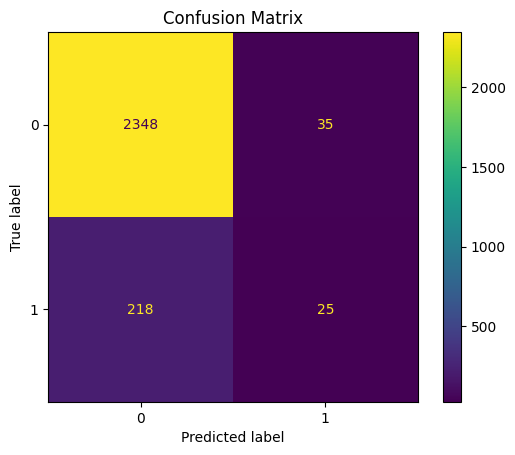

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

In [34]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.92      0.99      0.95      2383
         Yes       0.42      0.10      0.17       243

    accuracy                           0.90      2626
   macro avg       0.67      0.54      0.56      2626
weighted avg       0.87      0.90      0.88      2626



# randomforestclasifier

# libraries

In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# dataset

In [36]:
# Load dataset
data = pd.read_csv('/content/heart_2020_cleaned.csv')
data.head()
data.columns

Index(['HeartDisease', 'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke',
       'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory',
       'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'SleepTime',
       'Asthma', 'KidneyDisease', 'SkinCancer'],
      dtype='object')

In [37]:
#  Feature

data['HealthScore'] = data['PhysicalHealth'] + data['MentalHealth']

In [38]:
print(data)

       HeartDisease    BMI Smoking AlcoholDrinking Stroke  PhysicalHealth  \
0                No  16.60     Yes              No     No             3.0   
1                No  20.34      No              No    Yes             0.0   
2                No  26.58     Yes              No     No            20.0   
3                No  24.21      No              No     No             0.0   
4                No  23.71      No              No     No            28.0   
...             ...    ...     ...             ...    ...             ...   
319790          Yes  27.41     Yes              No     No             7.0   
319791           No  29.84     Yes              No     No             0.0   
319792           No  24.24      No              No     No             0.0   
319793           No  32.81      No              No     No             0.0   
319794           No  46.56      No              No     No             0.0   

        MentalHealth DiffWalking     Sex  AgeCategory      Race Diabetic  \

In [39]:

#  Binary Encoding
binary_cols = [
    'Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking',
    'PhysicalActivity', 'Asthma', 'KidneyDisease', 'SkinCancer'
]

for col in binary_cols:
    data[col] = data[col].map({'Yes': 1, 'No': 0})

In [40]:
print(data)

       HeartDisease    BMI  Smoking  AlcoholDrinking  Stroke  PhysicalHealth  \
0                No  16.60        1                0       0             3.0   
1                No  20.34        0                0       1             0.0   
2                No  26.58        1                0       0            20.0   
3                No  24.21        0                0       0             0.0   
4                No  23.71        0                0       0            28.0   
...             ...    ...      ...              ...     ...             ...   
319790          Yes  27.41        1                0       0             7.0   
319791           No  29.84        1                0       0             0.0   
319792           No  24.24        0                0       0             0.0   
319793           No  32.81        0                0       0             0.0   
319794           No  46.56        0                0       0             0.0   

        MentalHealth  DiffWalking     S

In [41]:
#  Split Data

X = data.drop('HeartDisease', axis=1)
y = data['HeartDisease']

In [42]:
# Auto Column Detection

categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns


#  Preprocessing

preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])







#  Pipeline (Random Fores

In [43]:

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

#  5-Fold Cross Validation

In [44]:


kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(pipeline, X, y, cv=kfold, scoring='accuracy')

print("Fold-wise Accuracy:")
for i, score in enumerate(cv_scores, 1): #start with 1 not 0
    print(f"Fold {i}: {score:.4f}") # upto 4 deciml points

print("\nOverall CV Accuracy:", cv_scores.mean())

Fold-wise Accuracy:
Fold 1: 0.9028
Fold 2: 0.9056
Fold 3: 0.9044
Fold 4: 0.9042
Fold 5: 0.9035

Overall CV Accuracy: 0.9041073187510749


#  Train-Test Evaluation


In [45]:

#X_train, X_test, y_train, y_test = train_test_split(
 #   X, y, test_size=0.2, random_state=42
#)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Test Accuracy: 0.9019684485373443
Confusion Matrix:
 [[57006  1361]
 [ 4909   683]]


In [46]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

# Results
print("\nTest Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Test Accuracy: 0.9019684485373443

Confusion Matrix:
[[57006  1361]
 [ 4909   683]]

Classification Report:
              precision    recall  f1-score   support

          No       0.92      0.98      0.95     58367
         Yes       0.33      0.12      0.18      5592

    accuracy                           0.90     63959
   macro avg       0.63      0.55      0.56     63959
weighted avg       0.87      0.90      0.88     63959



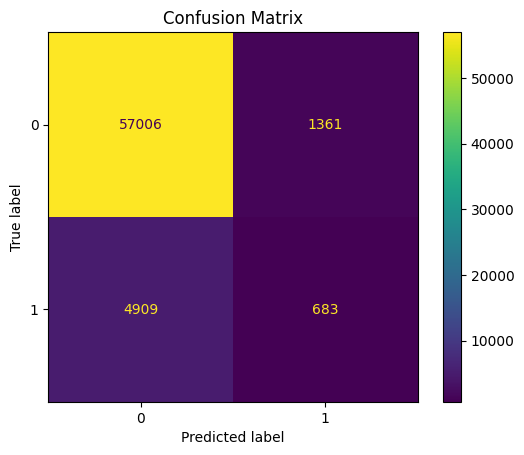

In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()